# General Overview

Dataset Resources: [UC Irvine's Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Diabetes+130-US+hospitals+for+years+1999-2008)

[Kaggle Link](https://www.kaggle.com/pavan2029/diabetic-data)

**Objective:**
Hospital readmission rates for certain conditions are now considered an indicator of hospital quality, and also affect the cost of care adversely. Hospital readmissions of diabetic patients are expensive as hospitals face penalties if their readmission rate is higher than expected and reflects the inadequacies in health care system. For these reasons, it is important for the hospitals to improve focus on reducing readmission rates. Identify the key factors that influence readmission for diabetes and to predict the probability of patient readmission. 

The dataset represents 10 years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. It includes over 50 features representing patient and hospital outcomes. The data contains such attributes as patient number, race, gender, age, admission type, time in hospital, medical specialty of admitting physician, number of lab test performed, HbA1c test result, diagnosis, number of medication, diabetic medications, number of outpatient, inpatient, and emergency visits in the year before the hospitalization, etc.*

### Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import re

# to avoid warnings
import warnings
warnings.filterwarnings('ignore')
warnings.warn("this will not show")

sns.set(style='darkgrid')
%matplotlib inline

### Import Dataset

In [ ]:
pd.read_csv('diabetic_data.zip').head()

In [ ]:
# csv contains "?" for missing values. We replace it with NaN
data = pd.read_csv('diabetic_data.zip', na_values=["?"])
df= data.copy()
df.head()

### Import Features Dataset
Descriptions of the features:
https://www.hindawi.com/journals/bmri/2014/781670/tab1/

In [ ]:
features = pd.read_csv('features.csv',index_col='Unnamed: 0')
info = lambda attribute:print(f"{attribute.upper()} : {features[features['Feature']==attribute]['Description'].values[0]}\n")
features.head()

In [ ]:
info('encounter_id')

### Check Duplicates

In [ ]:
df.duplicated().value_counts()
# df = df.drop_duplicates()

> no duplicates detected!

### Descriptive Analysis

In [ ]:
def summary(df, pred=None):
    obs = df.shape[0]
    Types = df.dtypes
    Counts = df.apply(lambda x: x.count())
    Min = df.min()
    Max = df.max()
    Uniques = df.apply(lambda x: x.unique().shape[0])
    Nulls = df.apply(lambda x: x.isnull().sum())
    print('Data shape:', df.shape)

    if pred is None:
        cols = ['Types', 'Counts', 'Uniques', 'Nulls', 'Min', 'Max']
        str = pd.concat([Types, Counts, Uniques, Nulls, Min, Max], axis = 1, sort=True)

    str.columns = cols
    print('___________________________\nData Types:')
    print(str.Types.value_counts())
    print('___________________________')
    return str

display(summary(df).sort_values(by='Nulls', ascending=False))

* 'citoglipton' and 'examide' features that the number of uniques is 1 are droped.
* all values of 'encounter_id' column are unique. It has to be droped.

In [ ]:
df = df.drop(['citoglipton','examide','encounter_id'],axis=1)

### FOCUS ON "Gender"

In [ ]:
df.gender.value_counts(dropna=False)

> We regard the observations of "Unknown/Invalid" gender as null values and drop them.

In [ ]:
gender_index = df[df.gender == 'Unknown/Invalid'].index
df = df.drop(gender_index, axis=0)

In [ ]:
# confirm removal
df.gender.value_counts(dropna=False)

### FOCUS ON "readmitted"

In [ ]:
df.readmitted.value_counts(dropna=False)

> Patients readmitted to the hospital within and after 30 days will be combined into one column, because these patients ultimately returned.

In [ ]:
df = df.replace(['<30', '>30'], 'YES')

### FOCUS  ON " patient_nbr "

In [ ]:
info('patient_nbr')

In [ ]:
df['patient_nbr'].duplicated().value_counts(dropna=False)

* we can think of 'patient_nbr' as the id number of each patient.
* It turned out that the dataset is the data of 71515 unique patients.
* Some patients visited the hospital multiple times for treatment so to avoid over-representing any particular individual, only the first encounter with a patient will be used / kept in this dataset.

In [ ]:
# total unique patients
len(df.patient_nbr), df.patient_nbr.nunique()

In [ ]:
# locate number of patient visits using patient_id
df.patient_nbr.value_counts()

In [ ]:
# keep only one record for each patient, the first visit
df = df.drop_duplicates(['patient_nbr'], keep='first')
df.shape

In [ ]:
df.patient_nbr.nunique()

* Since patient_nbr is unique, it is no longer needed.

In [ ]:
df = df.drop('patient_nbr', axis=1)

### Dropping irrelevant columns

In [ ]:
 def null_values(df):
    """a function to show null values with percentage"""
    nv=pd.concat([df.isnull().sum(), 100 * df.isnull().sum()/df.shape[0]],axis=1).rename(columns={0:'Missing_Records', 1:'Percentage (%)'})
    return nv[nv.Missing_Records>0].sort_values('Missing_Records', ascending=False)

In [ ]:
# columns with missing values
null_values(df)

In [ ]:
for i in ['weight','medical_specialty','payer_code']: info(i)

* The majority of patients do not have a weight listed so this column can be dropped. 
* Medical specialty and payer code are also missing for about half of the patients. 
* We do not need to know how the patients paid for their treatments.
* we do not have enough information to figure out which medical unit they went to.

In [ ]:
df = df.drop(['weight','medical_specialty','payer_code'], axis=1)

In [ ]:
summary(df).sort_values(by='Uniques', ascending=False)[:20]

In [ ]:
for i in ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']: info(i)

* We dont need 'admission_type_id', 'discharge_disposition_id', 'admission_source_id' columns

In [ ]:
# drop columns
drop_cols = ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']
df = df.drop(drop_cols, axis=1)

### Handling Missing Values

In [ ]:
null_values(df)

In [ ]:
df.race.value_counts(dropna=False)

* Since there is no way to know the race of the patient using existing information, the best option is to remove those rows.

In [ ]:
df = df.dropna(axis=0, subset=['race'])
null_values(df)

In [ ]:
for i in ['diag_1', 'diag_2', 'diag_3']: info(i)

* You can reach the extensive diagnosis description on this website by querying with the ICD9 code:
http://icd9.chrisendres.com/

Now, we are down to three columns with missing information: diagnosis 1, 2, and 3. 
* Diagnosis 1 is described as the primary diagnosis made during the patient's visit while diagnosis 2 is the second and 3 is an any additional diagnoses made after that. 
* Looking at the patients' rows that are missing a primary diagnosis, most of them have a second diagnosis or even a third. 
* Since it doesn't make sense to have a second (or third) but not a primary diagnosis, we will remove these columns from the dataset.

In [ ]:
info('number_diagnoses')

In [ ]:
df[['diag_1', 'diag_2', 'diag_3','number_diagnoses']][df.diag_1.isnull() & df.diag_2.notnull() & df.diag_3.notnull() & df.number_diagnoses.notnull()]

The number of diagnoses column shows the total number of conditions a patient is diagnosed with. Only the first three are recorded, so those that are missing the first diagnosis but still a second or third are in error.

In [ ]:
# remove rows where diagnosis 1 is missing
df = df.dropna(axis=0, subset=['diag_1'])

There are two remaining diagnosis columns with missing values. Each number correlates to a specific condition so if there is a missing value, then it is likely that the patient only has one diagnosed condition. The number of diagnoses column lists the total number of diagnosed conditions. When looking at all three diagnosis columns, if the number is one, then diagnosis 2 and 3 can be filled in with a 0 to show that there is no additional diagnosis. If diagnosis 2 or 3 is missing a value and the number of diagnoses is greater than one, then some diagnoses were not recorded and the rows should be removed.

In [ ]:
null_values(df)

In [ ]:
df[['diag_1','diag_2', 'diag_3','number_diagnoses']][df.diag_2.isnull() & (df.diag_3.notnull()|(df.number_diagnoses > 1))]

In [ ]:
# remove rows where diagnosis 2 is missing and number of diagnoses is greater than 1
diag_2_indexes = df[df.diag_2.isnull() & (df.diag_3.notnull()|(df.number_diagnoses > 1))].index
df = df.drop(index = diag_2_indexes, axis=0)

In [ ]:
null_values(df)

Diagnosis 3 is the last column left with unaccounted missing values. Since some patients have 1 or 2 diagnosed conditions, the diagnosis 3 column is left intentionally blank. The goal here is to remove the rows that have a diagnoses number greater than two.

In [ ]:
# list of affected rows
df[['diag_1','diag_2', 'diag_3', 'number_diagnoses']][df.diag_3.isnull() & (df.number_diagnoses > 2)]

In [ ]:
# remove rows with missing diagnosis 3 and number of diagnoses is greater than 2
diag_3_indexes = df[(df.diag_3.isnull()) & (df.number_diagnoses > 2)].index
df = df.drop(index=diag_3_indexes, axis=0)

In [ ]:
null_values(df)

In [ ]:
sns.heatmap(df[['diag_1','diag_2', 'diag_3','number_diagnoses']].isnull(),yticklabels=False,cbar=False,cmap='viridis');

In [ ]:
# replace NaN with None in diagnosis 2 and 3 to show there is no additional diagnosis
df.fillna('None', inplace=True)

In [ ]:
# confirm there are no more NaN values
null_values(df)

### Grouping Diagnosis Codes

In [ ]:
summary(df[['diag_1','diag_2', 'diag_3']])

* 'diag_1','diag_2' and 'diag_3' columns contain codes for the types of conditions patients are diagnosed with. 
* There are too much unique codes throughout this dataset.
* We can group the related icd9 diagnosis codes among themselves. In this way, we use categorical group names instead of numerical codes.
* The grouping is based on the research paper table (https://www.hindawi.com/journals/bmri/2014/781670/tab2/)
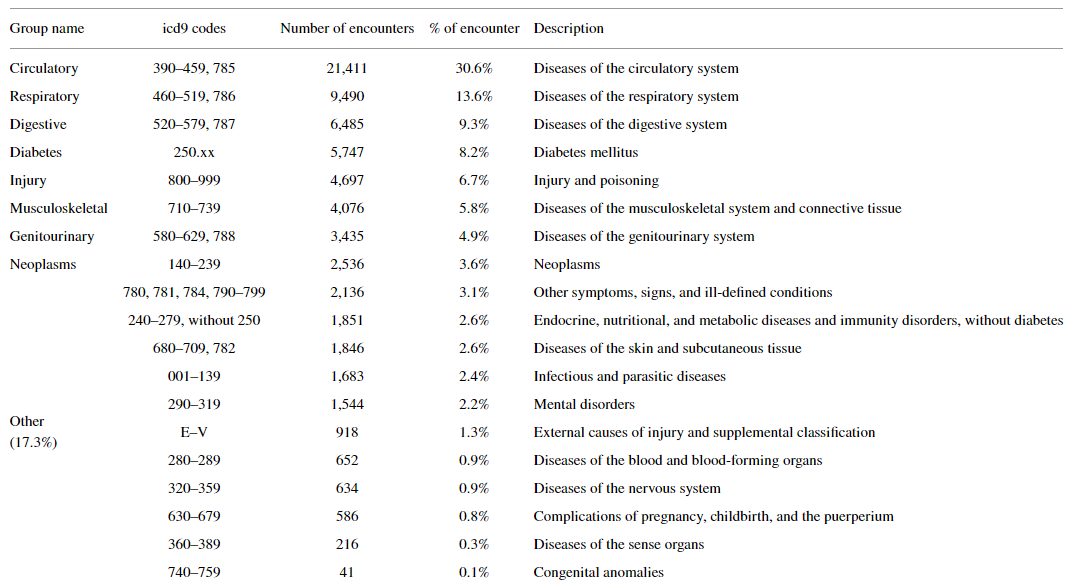

**Group Names**

    1-Circulatory
    2-Respiratory
    3-Digestive
    4-Diabetes
    5-Injury
    6-Musculoskeletal
    7-Genitourinary
    8-Neoplasms
    9-Other

In [ ]:
# Circulatory
codes =[str(i) for i in list(range(390,460)) + [785]]
df = df.replace(codes, 'Circulatory')

In [ ]:
# Respiratory
codes =[str(i) for i in list(range(460,520)) + [786]]
df = df.replace(codes, 'Respiratory')

In [ ]:
# Digestive
codes =[str(i) for i in list(range(520,580)) + [787]]
df = df.replace(codes, 'Digestive')

In [ ]:
# Diabetes
df = df.replace(regex=r'^250.*', value='Diabetes')

In [ ]:
# Injury
codes =[str(i) for i in range(800,1000)]
df = df.replace(codes, 'Injury')

In [ ]:
# Musculoskeletal
codes =[str(i) for i in range(710,740)]
df = df.replace(codes, 'Musculoskeletal')

In [ ]:
# Genitourinary
codes =[str(i) for i in list(range(580,630)) + [788]]
df = df.replace(codes, 'Genitourinary')

In [ ]:
# Neoplasms
codes =[str(i) for i in range(140,240)]
df = df.replace(codes, 'Neoplasms')

In [ ]:
# Other
df = df.replace(regex=r'^[E,V].*', value='Other')

codes =[str(i) for i in range(0,1000)]
df = df.replace(codes, 'Other')

In [ ]:
df[['diag_1', 'diag_2', 'diag_3']].head()

In [ ]:
# Unique Values of Each Features:
for i in df[['diag_1', 'diag_2', 'diag_3']]:
    print(f'{i}:\n{sorted(df[i].unique())}\n')

In [ ]:
# need to add 365.44 to Other
df = df.replace('365.44', 'Other') 

### Analysis of Diagnosis

In [ ]:
plt.figure(figsize=(20, 8))
for diag in ['diag_1','diag_2','diag_3']:
    sns.lineplot(x=df[diag].value_counts().sort_index().index, y= df[diag].value_counts().sort_index().values, marker='o')
plt.legend(['diag_1','diag_2','diag_3'])
plt.show()

* Looking at the graph above, we can say that there is a high correlation between the diagnoses. So we drop diag_2 and diag_3.
* Also since the most common diagnoses are prevalent in all three diagnoses listed, We are only using the primary diagnosis variable to build the machine learning model

In [ ]:
# drop diagnoses 2 and 3
df = df.drop(columns=['diag_2', 'diag_3'])

### FOCUS ON "`number_diagnoses`"

In [ ]:
plt.figure(figsize=(8,5))
ax = df.number_diagnoses.value_counts().sort_index().plot.bar()
def labels(ax, df=df):
    for p in ax.patches:
            ax.annotate('{:.0f}'.format(p.get_height()), 
                        (p.get_x(), p.get_height()+100),size=10)
labels(ax)

* For a small number of observations with number of diagnoses greater than 9, let's change the number of diagnoses to 9.

In [ ]:
df.number_diagnoses = df.number_diagnoses.replace([10,11,12,13,14,15,16],9)

### Outlier Detection

Based on the basic statistics describing the dataset, it looks there are outliers that influence skewness in the data. In order to represent the majority of samples and build clean models, we are going to remove outliers that have [z-scores](https://www.statisticshowto.datasciencecentral.com/probability-and-statistics/z-score/) greater than 3.0 or less than -3.0. This means that we are removing samples that are more (or less) than 3 times the standard deviation from the mean.

In [ ]:
df.describe().T

In [ ]:
features = df.describe().columns

In [ ]:
def col_plot(df,col_name):
    plt.figure(figsize=(15,6))
    
    plt.subplot(141) # 1 satir x 4 sutun dan olusan ax in 1. sutununda calis
    plt.hist(df[col_name], bins = 20)
    f=lambda x:(np.sqrt(x) if x>=0 else -np.sqrt(-x))
    
    # üç sigma aralikta(verinin %99.7 sini icine almasi beklenen bolum) iki kirmizi cizgi arasinda
    plt.axvline(x=df[col_name].mean() + 3*df[col_name].std(),color='red')
    plt.axvline(x=df[col_name].mean() - 3*df[col_name].std(),color='red')
    plt.xlabel(col_name)
    plt.tight_layout
    plt.xlabel("Histogram ±3z")
    plt.ylabel(col_name)

    plt.subplot(142)
    plt.boxplot(df[col_name]) # IQR katsayisi, defaultu 1.5
    plt.xlabel("IQR=1.5")

    plt.subplot(143)
    plt.boxplot(df[col_name].apply(f), whis = 2.5)
    plt.xlabel("ROOT SQUARE - IQR=2.5")

    plt.subplot(144)
    plt.boxplot(np.log(df[col_name]+0.1), whis = 2.5)
    plt.xlabel("LOGARITMIC - IQR=2.5")
    plt.show()

In [ ]:
for i in features:
    col_plot(df,i)

In [ ]:
from scipy.stats.mstats import winsorize

def plot_winsorize(df,col_name,up=0.1,down=0):
    plt.figure(figsize = (15, 6))

    winsor=winsorize(df[col_name], (down,up))
    logr=np.log(df[col_name]+0.1)

    plt.subplot(141)
    plt.hist(winsor, bins = 22)
    plt.axvline(x=winsor.mean()+3*winsor.std(),color='red')
    plt.axvline(x=winsor.mean()-3*winsor.std(),color='red')
    plt.xlabel('Winsorize_Histogram')
    plt.ylabel(col_name)
    plt.tight_layout

    plt.subplot(142)
    plt.boxplot(winsor, whis = 1.5)
    plt.xlabel('Winsorize - IQR:1.5')
    
    plt.subplot(143)
    plt.hist(logr, bins=22)
    plt.axvline(x=logr.mean()+3*logr.std(),color='red')
    plt.axvline(x=logr.mean()-3*logr.std(),color='red')
    plt.xlabel('Logr_col_name')

    plt.subplot(144)
    plt.boxplot(logr, whis = 1.5)
    plt.xlabel("Logaritmic - IQR=1.5")
    plt.show()    


In [ ]:
for i in features:
    plot_winsorize(df,i)

In [ ]:
df_winsorised=df.copy()
for i in features:
    df_winsorised[i]=winsorize(df_winsorised[i], (0,0.1))

In [ ]:
df_log=df.copy()
for i in features:
    df_log[i]=np.log(df_log[i])

In [ ]:
df_root=df.copy()
f=lambda x:(np.sqrt(x) if x>=0 else -np.sqrt(-x))
for i in features:
    df_root[i]=df_root[i].apply(f)

In [ ]:
from numpy import percentile
from scipy.stats import zscore
from scipy import stats

def outlier_zscore(df, col, min_z=1, max_z = 5, step = 0.1, print_list = False):
    z_scores = zscore(df[col].dropna())
    threshold_list = []
    for threshold in np.arange(min_z, max_z, step):
        threshold_list.append((threshold, len(np.where(z_scores > threshold)[0])))
        df_outlier = pd.DataFrame(threshold_list, columns = ['threshold', 'outlier_count'])
        df_outlier['pct'] = (df_outlier.outlier_count - df_outlier.outlier_count.shift(-1))/df_outlier.outlier_count*100
    plt.plot(df_outlier.threshold, df_outlier.outlier_count)
    best_treshold = round(df_outlier.iloc[df_outlier.pct.argmax(), 0],2)
    outlier_limit = int(df[col].dropna().mean() + (df[col].dropna().std()) * df_outlier.iloc[df_outlier.pct.argmax(), 0])
    percentile_threshold = stats.percentileofscore(df[col].dropna(), outlier_limit)
    plt.vlines(best_treshold, 0, df_outlier.outlier_count.max(), 
               colors="r", ls = ":"
              )
    plt.annotate("Zscore : {}\nValue : {}\nPercentile : {}".format(best_treshold, outlier_limit, 
                                                                   (np.round(percentile_threshold, 3), 
                                                                    np.round(100-percentile_threshold, 3))), 
                 (best_treshold, df_outlier.outlier_count.max()/2))
    #plt.show()
    if print_list:
        print(df_outlier)
    return (plt, df_outlier, best_treshold, outlier_limit, percentile)

In [ ]:
from scipy.stats import zscore
from scipy import stats

def outlier_inspect(df, col, min_z=1, max_z = 5, step = 0.5, max_hist = None, bins = 50):
    fig = plt.figure(figsize=(20, 6))
    fig.suptitle(col, fontsize=16)
    plt.subplot(1,3,1)
    if max_hist == None:
        sns.distplot(df[col], kde=False, bins = 50)
    else :
        sns.distplot(df[df[col]<=max_hist][col], kde=False, bins = 50)
   
    plt.subplot(1,3,2)
    sns.boxplot(df[col])
    plt.subplot(1,3,3)
    z_score_inspect = outlier_zscore(df, col, min_z=min_z, max_z = max_z, step = step)
    
    plt.subplot(1,3,1)
    plt.axvline(x=df[col].mean() + z_score_inspect[2]*df[col].std(),color='red',linewidth=1,linestyle ="--")
    plt.axvline(x=df[col].mean() - z_score_inspect[2]*df[col].std(),color='red',linewidth=1,linestyle ="--")
    plt.show()
    
    return z_score_inspect

In [ ]:
def detect_outliers(df:pd.DataFrame, col_name:str, p=1.5) ->int:
    ''' 
    this function detects outliers based on 3 time IQR and
    returns the number of lower and uper limit and number of outliers respectively
    '''
    first_quartile = np.percentile(np.array(df[col_name].tolist()), 25)
    third_quartile = np.percentile(np.array(df[col_name].tolist()), 75)
    IQR = third_quartile - first_quartile
                      
    upper_limit = third_quartile+(p*IQR)
    lower_limit = first_quartile-(p*IQR)
    outlier_count = 0
                      
    for value in df[col_name].tolist():
        if (value < lower_limit) | (value > upper_limit):
            outlier_count +=1
    return lower_limit, upper_limit, outlier_count

In [ ]:
k=3
print(f"Number of Outliers for {k}*IQR\n")

total=0
for col in features:
    if detect_outliers(df, col)[2] > 0:
        outliers=detect_outliers(df, col, k)[2]
        total+=outliers
        print("{} outliers in '{}'".format(outliers,col))
print("\n{} OUTLIERS TOTALLY".format(total))

In [ ]:
k=3
print(f"Number of Outliers for {k}*IQR after Root Square\n")

total=0
for col in features:
    if detect_outliers(df_root, col)[2] > 0:
        outliers=detect_outliers(df_root, col, k)[2]
        total+=outliers
        print("{} outliers in '{}'".format(outliers,col))
print("\n{} OUTLIERS TOTALLY".format(total))

In [ ]:
k=3
print(f"Number of Outliers for {k}*IQR after Winsorised\n")

total=0
for col in features:
    if detect_outliers(df_winsorised, col)[2] > 0:
        outliers=detect_outliers(df_winsorised, col, k)[2]
        total+=outliers
        print("{} outliers in '{}'".format(outliers,col))
print("\n{} OUTLIERS TOTALLY".format(total))

In [ ]:
k=3
print(f"Number of Outliers for {k}*IQR after Logarithmed\n")

total=0
for col in features:
    if detect_outliers(df_log, col)[2] > 0:
        outliers=detect_outliers(df_log, col, k)[2]
        total+=outliers
        print("{} outliers in '{}'".format(outliers,col))
print("\n{} OUTLIERS TOTALLY".format(total))

In [ ]:
z_scores=[]
for i in features:
    z_scores.append(outlier_inspect(df,i)[2])

In [ ]:
z_scores

In [ ]:
features

In [ ]:
# create columns for z scores, new column with z score
df_3z=df.copy()

for x in features:
    df_3z[x + '_z'] = stats.zscore(df_3z[x])

for x in df_3z.columns[-len(features):]:
    df_3z = df_3z[(df_3z[x] < 3) & (df_3z[x] > -3)]
    
# drop _z columns
df_3z = df_3z.drop(columns=df_3z.columns[-8:])

print('Number of Outliers:',len(df)-len(df_3z))

In [ ]:
df_3z.describe().T.round(2)

In [ ]:
df.describe().T.round(2)

### Check Unique Values

Investigate the unique values of each column and look for error entries.

In [ ]:
summary(df_3z)

> Drop the columns that the number of uniques is 1

In [ ]:
df_3z = df_3z.drop(['acetohexamide','glimepiride-pioglitazone','metformin-rosiglitazone'],axis=1)

### Export Cleaned Dataset

In [ ]:
df_3z = df_3z.reset_index(drop=True)
df_3z.to_csv('diabetic_data_cleaned.csv')

# Visualization

* We are looking for correlations between the independent variables and the target variable, the likelihood of being readmitted to the hospital, using graphs and plots. 
* This is also a good time to get a better understanding of patient demographics, their experiences at the hospital, medications being used / not used, and any diagnosed conditions.

### Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pylab import rcParams
rcParams['figure.figsize'] = 12,6

# to avoid warnings
import warnings
warnings.filterwarnings('ignore')
warnings.warn("this will not show")

sns.set(style='darkgrid')
%matplotlib inline

### Import Dataset

In [ ]:
data = pd.read_csv('diabetic_data_cleaned.csv', index_col=0)
df = data.copy()
df.head()

In [ ]:
features = pd.read_csv('features.csv',index_col='Unnamed: 0')
info = lambda attribute:print(f"{attribute.upper()} : {features[features['Feature']==attribute]['Description'].values[0]}\n")
features.head()

In [ ]:
def summary(df, pred=None):
    obs = df.shape[0]
    Types = df.dtypes
    Counts = df.apply(lambda x: x.count())
    Min = df.min()
    Max = df.max()
    Uniques = df.apply(lambda x: x.unique().shape[0])
    Nulls = df.apply(lambda x: x.isnull().sum())
    print('Data shape:', df.shape)

    if pred is None:
        cols = ['Types', 'Counts', 'Uniques', 'Nulls', 'Min', 'Max']
        str = pd.concat([Types, Counts, Uniques, Nulls, Min, Max], axis = 1, sort=True)

    str.columns = cols
    print('___________________________\nData Types:')
    print(str.Types.value_counts())
    print('___________________________')
    return str

summary(df)

In [ ]:
round(df.describe(), 2)

In [ ]:
df.shape

In [ ]:
sns.pairplot(df, hue='readmitted');

In [ ]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm");

### FOCUS ON "readmitted" patients overall

In [ ]:
info('readmitted')

In [ ]:
def labels(ax):
    for p in ax.patches:
            ax.annotate('%{:.1f}\n{:.0f}'.format(100*p.get_height()/len(df),p.get_height()), 
                        (p.get_x()+0.3, p.get_height()-1900),size=11)

ax = sns.countplot(x='readmitted', palette='husl', data=df)
labels(ax)

# sns.catplot(x='readmitted', kind='count', palette='husl', data=df)  # alternative
plt.title('Readmit Rates')
plt.show()

### FOCUS ON "race"

In [ ]:
def labels(ax):
    for bar in ax.patches: 
        ax.annotate('%{:.1f}\n{:.0f}'.format(100*bar.get_height()/len(df),bar.get_height()), (bar.get_x() + bar.get_width() / 2,  
                        bar.get_height()), ha='center', va='center', 
                       size=10, xytext=(0, 8), 
                       textcoords='offset points') 

rcParams['figure.figsize'] = 12,6
ax = sns.countplot(x='race', hue='readmitted', palette='husl', data=df)
labels(ax)
# sns.catplot(x='race', hue='readmitted', kind='count', palette='husl', data=df, aspect=2, legend_out=False)
plt.title('Patient Demographic Readmissions')
plt.show()

In [ ]:
pd.crosstab(df.race, df.readmitted, margins=True, margins_name='Total')

### FOCUS ON "gender"

In [ ]:
rcParams['figure.figsize'] = 12,6
ax = sns.countplot(x='gender', hue='readmitted', palette='husl', data=df)
labels(ax)
plt.title('Readmissions by Gender')
plt.show()

In [ ]:
pd.crosstab(df.gender, df.readmitted, margins=True, margins_name='Total')

### FOCUS ON "age" groups

In [ ]:
ax = sns.countplot(x='age', palette='husl', data=df.sort_values('age'))
labels(ax)
plt.title('Patient Demographics')
plt.show()

> It looks like most patients are older, 50+ years old, though there aren't many patients over 90.

In [ ]:
ax = sns.countplot(x='age', hue='readmitted', palette='husl', data=df.sort_values('age'))
labels(ax)
plt.title('Readmits By Age Group')
plt.show()

In [ ]:
pd.crosstab(df.age, df.readmitted, margins=True, margins_name='Total').T

>In every age group, more patients are not readmitted. The 70-80 age group account has the highest number of readmitted and not readmitted patients.

### FOCUS ON "time_in_hospital"

In [ ]:
sns.countplot(x='time_in_hospital', palette='muted', data=df)
mean, median = np.mean(df.time_in_hospital), np.median(df.time_in_hospital)
plt.axvline(mean-df.time_in_hospital.min(), color='blue', label=f'mean:{round(mean,2)}')
plt.axvline(median-df.time_in_hospital.min(), color='red', label=f'median:{round(median,2)}')
plt.title('Duration of Hospital Visit in Days')
plt.legend()
plt.show()

> **Does the amount of time spent in the hospital impact a patient's chances of readmission?**

In [ ]:
sns.catplot(x='time_in_hospital', hue='readmitted', kind='count', palette='husl', aspect=3, data=df, legend_out=False)
plt.title('Readmission Based on Time in Hospital')
plt.show()

In [ ]:
sns.displot(x='time_in_hospital', hue='readmitted', data=df, height=7, aspect=3)
plt.title('Readmission Based on Time in Hospital')
plt.show()

> Based on the graph, the longer a patient spends in the hospital, the likelier their chances are of being readmitted. Patients who spend more than a week in the hospital usually have a serious illness or complication that may reoccur depending on their ability to recover, which is why they may need to revisit the hospital.

> **Which age group is spending the most time in hospitals during visits?**

In [ ]:
def box_labels(ax, df,col1,col2):
    medians = df.groupby([col1])[col2].median()
    vertical_offset = df[col2].median() * 0.05 # offset from median for display

    for xtick in ax.get_xticks():
        ax.text(xtick,medians[xtick] + vertical_offset,medians[xtick], 
                horizontalalignment='center',size='x-small',color='w',weight='semibold')

ax = sns.boxplot(x='age', y='time_in_hospital', data=df.sort_values('age'))
box_labels(ax, df.sort_values('age'),'age','time_in_hospital')    
plt.title('Length of Hospital Stay Based on Age')
plt.show()

> **What is the comparison of time in hospital for readmitted patients?**

In [ ]:
ax = sns.boxplot(x='readmitted', y='time_in_hospital', data=df.sort_values('readmitted'))
box_labels(ax, df.sort_values('readmitted'),'readmitted','time_in_hospital') 
plt.title('Length of Hospital Stay for Readmitted Patients')
plt.show()

> Readmitted patients stay longer in the hospital on average compared to those who are not readmitted.

### FOCUS ON "number of lab procedures`

In [ ]:
info("num_lab_procedures")

In [ ]:
rcParams['figure.figsize'] = 25,10
sns.countplot(x='num_lab_procedures', data=df)
mean, median = np.mean(df.num_lab_procedures), np.median(df.num_lab_procedures)
plt.axvline(mean-df.num_lab_procedures.min(), color='blue', label=f'mean:{round(mean,2)}')
plt.axvline(median-df.num_lab_procedures.min(), color='black', label=f'median:{round(median,2)}')
plt.title('Number of Lab Procedures Performed During Visit')
plt.legend()
plt.show()

In [ ]:
df.groupby('readmitted')['num_lab_procedures'].describe().round(2)

> **Do the patients with longer hospital stays have more lab tests?**

In [ ]:
def box_labels(ax, df,col1,col2):
    medians = df.groupby([col1])[col2].median()
    vertical_offset = df[col2].median() * 0.05 # offset from median for display

    for xtick in ax.get_xticks():
        ax.text(xtick,medians[xtick] + vertical_offset,medians[xtick], 
                horizontalalignment='center',size=12,color='w',weight='semibold')

ax = sns.boxplot(x='time_in_hospital', y='num_lab_procedures', data=df.sort_values('time_in_hospital'))
# box_labels(ax, df.sort_values('time_in_hospital'),'time_in_hospital','num_lab_procedures') 
plt.title('Lab Procedures Based on Length of Hospital Visit')
plt.show()

* There is a positive correlation between time spent in the hospital and number of lab tests completed. 
* This makes sense since patients with longer stays had more tests completed to properly diagnose their conditions.

> **Do readmitted patients have more lab tests?**

In [ ]:
plt.figure(figsize=(10, 8))
ax = sns.boxplot(x='readmitted', y='num_lab_procedures', data=df.sort_values('readmitted'))
box_labels(ax, df.sort_values('readmitted'),'readmitted','num_lab_procedures') 
plt.title('Lab Procedures for Readmitted Patients')
plt.show()

* The average number of lab procedures is about equal for readmitted and not readmitted patients. 
* Not readmitted patients have a slightly lower number of lab procedures done during their visit.

### FOCUS ON "`number of procedures`" (other than lab)

In [ ]:
info('num_procedures')

In [ ]:
sns.catplot(x='num_procedures', kind='count', palette='muted', data=df)
mean, median = np.mean(df.num_procedures), np.median(df.num_procedures)
plt.axvline(mean, color='blue', label=f'mean:{round(mean,2)}')
plt.axvline(median, color='black', label=f'median:{round(median,2)}')
plt.title('Number of Procedures Performed (Except Lab)')
plt.legend()
plt.show()

> **Do the number of tests performed indicate whether a patient will be readmitted?**

In [ ]:
def labels(ax):
    for bar in ax.patches: 
        ax.annotate('%{:.1f}\n{:.0f}'.format(100*bar.get_height()/len(df),bar.get_height()), (bar.get_x() + bar.get_width() / 2,  
                        bar.get_height()-400), ha='center', va='center', 
                       size=14, xytext=(0, 8), 
                       textcoords='offset points') 
        
ax = sns.countplot(x='num_procedures', hue='readmitted', palette='husl', data=df)
labels(ax)
plt.title('Readmits Based on Procedures (Sans Lab)')
plt.show()

### FOCUS ON "number of medications"

In [ ]:
info('num_medications')

In [ ]:
rcParams['figure.figsize'] = 25,10
sns.countplot(x='num_medications', data=df)
mean, median = np.mean(df.num_medications), np.median(df.num_medications)
plt.axvline(mean-df.num_medications.min(), color='blue', label=f'mean:{round(mean,2)}')
plt.axvline(median-df.num_medications.min(), color='black', label=f'median:{round(median,2)}')
plt.title('Number of Distinct Generic Medications Administered During Visit')
plt.legend()
plt.show()

In [ ]:
df.groupby('readmitted')['num_medications'].describe()

> **How many medications are patients receiving during their visit?**

In [ ]:
ax = sns.boxplot(x='time_in_hospital', y='num_medications', data=df)
# box_labels(ax, df.sort_values('time_in_hospital'),'time_in_hospital','num_medications')
plt.title('Medications Administered Based on Length of Hospital Visit')
plt.show()

> Patients who spend more time in the hospital receive more medications, but there are a few that receive over 60 different kinds of medications.

> **How many medications are patients receiving during their visit?**

In [ ]:
ax = sns.boxplot(x='readmitted', y='num_medications', data=df.sort_values('readmitted'))
box_labels(ax, df.sort_values('readmitted'),'readmitted','num_medications')
plt.title('Medications Administered')
plt.show()

> The distribution is almost equal for readmitted and not readmitted patients, with readmits being slightly higher on average.

### FOCUS ON "`number of outpatient`" visits

In [ ]:
info('number_outpatient')

In [ ]:
def labels(ax):
    for bar in ax.patches: 
        ax.annotate('%{:.1f}\n{:.0f}'.format(100*bar.get_height()/len(df),bar.get_height()), (bar.get_x() + bar.get_width() / 2,  
                        bar.get_height()+750), ha='center', va='center', 
                       size=16, xytext=(0, 8), 
                       textcoords='offset points') 
        
ax = sns.countplot(x='number_outpatient',data=df)
labels(ax)
plt.title('Number of Outpatient Visits Prior to Encounter')
plt.show()

In [ ]:
# outpatient visit stats
df.groupby('readmitted')['number_outpatient'].describe()

In [ ]:
# outpatient vists and readmissions
ax = sns.countplot(x='number_outpatient',data=df, hue='readmitted')
labels(ax)
plt.title('Outpatient Vists and Readmissions')
plt.show()

In [ ]:
pd.crosstab(df.readmitted, df.number_outpatient, margins=True, margins_name='Total')

> Most patients did not have any outpatient visits prior to the recorded one.

### FOCUS ON "`number of emergency`" visits

In [ ]:
info('number_emergency')

In [ ]:
# plt.figure(figsize=(20,5))
ax = sns.countplot(x='number_emergency', data=df)
labels(ax)
plt.title('Number of Emergency Visits Prior to Encounter')
plt.show()

In [ ]:
# emergency vists and readmissions
ax = sns.countplot(x='number_emergency', hue='readmitted', data=df)
labels(ax)
plt.title('Emergency Vists and Readmissions')
plt.show()

> Most patients did not visit the emergency room prior to their recorded visit.

In [ ]:
pd.crosstab(df.readmitted, df.number_emergency, margins=True, margins_name='Total')

> **How many emergency visits did patients have prior to this visit?**

In [ ]:
plt.figure(figsize=(5, 5))
sns.boxplot(x='readmitted', y='number_emergency', data=df)
plt.title('Readmits for Emergency Vists')
plt.show()

### FOCUS ON "`number of inpatient`" visits

In [ ]:
info('number_inpatient') # onceki yildaki yatarak tedavi sayisi

In [ ]:
ax = sns.countplot(x='number_inpatient',data=df)
labels(ax)
plt.title('Number of Inpatient Visits Prior to Encounter')
plt.show()

In [ ]:
# inpatient visits and readmissions
ax = sns.countplot(x='number_inpatient', hue='readmitted',data=df)
labels(ax)
plt.title('Inpatient Visits and Readmissions')
plt.show()

> Inpatient visits are not common for most patients prior to this visit.

In [ ]:
pd.crosstab(df.readmitted, df.number_inpatient, margins=True, margins_name='Total')

### FOCUS ON "`number of diagnoses`"

In [ ]:
info('number_diagnoses')

In [ ]:
ax = sns.countplot(x='number_diagnoses',data=df)
mean, median = np.mean(df.number_diagnoses), np.median(df.number_diagnoses)
plt.axvline(mean-df.number_diagnoses.min(), color='blue', label=f'mean:{round(mean,2)}')
plt.axvline(median-df.number_diagnoses.min(), color='red', label=f'median:{round(median,2)}')
plt.title('Number of Diagnoses')
plt.legend()
plt.show()

In [ ]:
# number of diagnoses and readmit rate
ax = sns.countplot(x='number_diagnoses', hue='readmitted', palette='Accent', data=df)
# labels(ax)
plt.title('Readmits By Number of Diagnoses')
plt.show()

In [ ]:
pd.DataFrame(df.number_diagnoses.describe()).T.round(2)

In [ ]:
df.groupby('readmitted')['number_diagnoses'].describe().round(2)

In [ ]:
# number of diagnoses
pd.crosstab(df.readmitted, df.number_diagnoses, margins=True, margins_name='Total')

* Most patients have up to nine diagnosed conditions during their visit, after that, only a handful have more than nine in one visit. 
* Readmitted patients tend to have more diagnosed conditions but their average is only slightly higher than those not readmitted.

> **How many diagnoses do readmitted patients have?**

In [ ]:
plt.figure(figsize=(8, 6))
ax = sns.boxplot(x='readmitted', y='number_diagnoses', data=df.sort_values('readmitted'))
box_labels(ax, df.sort_values('readmitted'),'readmitted','number_diagnoses')
plt.title('Number of Diagnoses for Re/admitted Patients')
plt.show()

# FOCUS ON "`glucose serum test results`"

In [ ]:
info('max_glu_serum')

In [ ]:
ax = sns.countplot(x='max_glu_serum', data=df)
labels(ax)
plt.title('Glucose Serum Test Results')
plt.show()

> Since the majority of patients do not have a glucose reading, they will be excluded for the next graph in order to show the readmit rates for patients who do have a reading.

In [ ]:
def labels(ax, df=df):
    for p in ax.patches:
            ax.annotate('%{:.1f}\n{:.0f}'.format(100*p.get_height()/len(df),p.get_height()), 
                        (p.get_x()+0.2, p.get_height()-27),size=16)

# exclude patients without a glucose reading
glucose_none = df[df.max_glu_serum != 'None']

# glucose serum results and readmit impact
ax = sns.countplot(x='max_glu_serum', hue='readmitted', palette='Accent', data=glucose_none)
labels(ax,glucose_none)
plt.title('Readmits By Glucose Serum Levels')
plt.show()

Patients with a glucose serum reading of over 300 have a 50-50 chance of being readmitted. High blood sugar levels are often dangerous for older patients due to the medical complications involved, so it's understandable that more patients return to the hospital for additional care.

In [ ]:

pd.crosstab(df.readmitted, df.max_glu_serum, margins=True, margins_name='Total')

### FOCUS ON "`A1C results`"

In [ ]:
info('A1Cresult')

In [ ]:
ax = sns.countplot(x='A1Cresult', palette='husl', data=df)
labels(ax)
plt.title('A1c Test Results')
plt.show()

* Similar to the glucose reading, the majority of patients also do not have a HbA1c test reading. 
* In order to understand the impact of A1c tests on readmit rates, patients without a reading will be excluded in the graph below.

In [ ]:
# exclude patients without an A1C reading
alc_none = df[df.A1Cresult != 'None']

# A1C results and readmit impact
ax = sns.countplot(x='A1Cresult', hue='readmitted', palette='Accent', data=alc_none)
labels(ax, alc_none)
plt.title('Readmits By A1C Test Results')
plt.show()

In [ ]:
pd.crosstab(df.readmitted, df.A1Cresult, margins=True, margins_name='Total')

### FOCUS ON "`change`" column

In [ ]:
info('change')

## change in medications, dosage or brand

In [ ]:
# change in medications
ax = sns.countplot(x='change', hue='readmitted', data=df)
labels(ax)
plt.title('Change in Diabetic Medications')
plt.show()

In [ ]:
pd.crosstab(df.change, df.readmitted, margins=True, margins_name='Total')

> **who is likely to have a change in medication?**

In [ ]:
ax = sns.countplot(x='gender', hue='change', palette='Set2', data=df)
labels(ax)
plt.title('Change in Medication Based on Gender')
plt.show()

In [ ]:
pd.crosstab(df.gender, df.change, margins=True, margins_name='Total')

### FOCUS ON "`diabetesMed`"

In [ ]:
info('diabetesMed')

In [ ]:
ax = sns.countplot(x='diabetesMed', hue='readmitted', data=df)
labels(ax)
plt.title('Prescribed Diabetic Medications During Visit')
plt.show()

In [ ]:
pd.crosstab(df.diabetesMed, df.readmitted, margins=True, margins_name='Total')

> **Who is likely or not likely to have a change in medication?**

In [ ]:
sns.catplot(x='diabetesMed', hue='readmitted', col='gender', palette='Accent', data=df, kind='count', height=4, aspect=1)
plt.show()

### medications used by patients

In [ ]:
columns=['metformin', 'repaglinide', 'nateglinide',
       'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide',
       'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol',
       'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin',
       'glipizide-metformin', 'metformin-pioglitazone']

plt.figure(figsize=(26, 26))
for i,col in enumerate(columns):
    plt.subplot(6,3,i+1)
    sns.countplot(x=df[col])

> Dosages for insulin shows the most activity out of all diabetic medications, most of which aren't prescribed to patients.

In [ ]:
info('insulin')

In [ ]:
sns.countplot(x='insulin', hue='readmitted', data=df)
plt.title('Readmit Rates by Medication: Insulin')
plt.show()

# General Overview - Statistical Analysis

* We want to analyze the variables in this dataset to understand any relationships between them and their overall effects.
* To do this,
        * `Chi-square test` for categorical variables relationship
        * We have to analyze numerical variables using `analysis of variance` or `ANOVA test`.
* The purpose of these tests is to determine whether there is a statistically significant relationship between the target variable, readmissions and independent variable. Our p-value is 0.01, if anything above that, we cannot reject the null hypothesis.
* A machine learning model can interpret integers as well as process strings, so we must transform all categorical variables using dummy variables as numeric variables. This takes the string values ​​in a variable and converts them to columns labeled 0 or 1 relative to the string. We will also standardize the original numerical variables with a mean of 0 and a standard deviation of 1.
* Finally, we look at the correlation coefficients between the independent variables to make sure they do not have a strong influence on each other. The threshold we used is -0.7 <x <0.7.



### Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pylab import rcParams
rcParams['figure.figsize'] = 12,6

# to avoid warnings
import warnings
warnings.filterwarnings('ignore')
warnings.warn("this will not show")

sns.set(style='darkgrid')
%matplotlib inline

import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.stats import chi2_contingency
from numpy.random import seed
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

In [ ]:
data = pd.read_csv('diabetic_data_cleaned.csv', index_col=0) # import data
df = data.copy() # save a copy of data as diabetes

In [ ]:
features = pd.read_csv('features.csv',index_col='Unnamed: 0')
info = lambda attribute:print(f"{attribute.upper()} : {features[features['Feature']==attribute]['Description'].values[0]}\n")

In [ ]:
def summary(df, pred=None):
    obs = df.shape[0]
    Types = df.dtypes
    Counts = df.apply(lambda x: x.count())
    Min = df.min()
    Max = df.max()
    Uniques = df.apply(lambda x: x.unique().shape[0])
    Nulls = df.apply(lambda x: x.isnull().sum())
    print('Data shape:', df.shape)

    if pred is None:
        cols = ['Types', 'Counts', 'Uniques', 'Nulls', 'Min', 'Max']
        str = pd.concat([Types, Counts, Uniques, Nulls, Min, Max], axis = 1, sort=True)

    str.columns = cols
    print('___________________________\nData Types:')
    print(str.Types.value_counts())
    print('___________________________')
    return str

summary(df)

In [ ]:
df.describe().round(2).T

In [ ]:
plt.figure(figsize=(6,6))

explode = [0,0.1]
plt.pie(df['readmitted'].value_counts(),explode=explode,autopct='%1.1f%%',shadow=True,startangle=60)
plt.legend(labels=df.readmitted.value_counts().index)
plt.title('Readmitted Patients')
plt.axis('off')
plt.show()

## Feature Selection
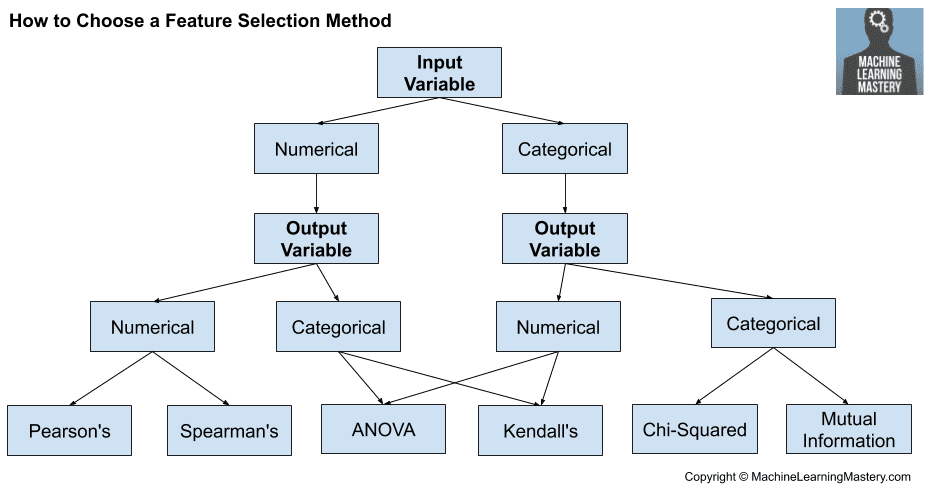

### categorical variables

In [ ]:
print('Unique Values of Each Features:\n')
for i in df:
    print(f'{i}:\n{sorted(df[i].unique())}\n')

In [ ]:
categorical=df.select_dtypes(include='object').columns.tolist()
print(categorical)

* The categorical variables are: 
<br>`['race', 'gender', 'age', 'diag_1', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']`


* We are using the chi-square test for association with a p-value of 0.01 to reject the null hypothesis.

## chi-square test for association

In [ ]:
# define a function that returns a table, a chi-square value, and a p value
def chisquare_test(df, var_list, target, null_list=[]):
    for var in var_list:
        print(var.upper())
        chi_test = pd.crosstab(df[var], df[target])
        display(chi_test)
    
        chisq_value, pvalue, dataframe, expected = chi2_contingency(chi_test)
    
        print(f"""Chi-square value: {chisq_value:.2f}
p-value\t\t: {pvalue:.3f}\n""")
        
        if pvalue > 0.01: # adds variables that fail to reject the null hypothesis
            null_list.append(var)
            
    print(f'Fail to reject null hypothesis: {null_list}')

In [ ]:
cols_cat = ['race','gender', 'age', 'diag_1', 'max_glu_serum', 'A1Cresult', 'change', 'diabetesMed']
null_list=[]
chisquare_test(df, cols_cat,'readmitted',null_list)

> Based on the chi-square value and p-value, we can safely say that there is no relation between the independent variables and the target variable.

### medications

In [ ]:
medications = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 
            'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 
               'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 
               'insulin', 'glyburide-metformin', 'glipizide-metformin', 'metformin-pioglitazone']
chisquare_test(df, medications,'readmitted', null_list)

* The medications: nateglinide, chlorpropamide, glimepiride, acetohexamide, glyburide, tolbutamide, miglitol, troglitazone, tolazamide, glyburide-metformin, glipizide-metformin, and metformin-pioglitazone all failed to pass the test since they have p-values greater than 0.01.

* Since these variables are not independent of the target variable, we are removing them from the dataset.

In [ ]:
print(null_list)

In [ ]:
# drop columns that do not pass the p-value test
df = df.drop(columns=null_list)

# numerical variables

## statistical testing - analysis of variance (ANOVA)

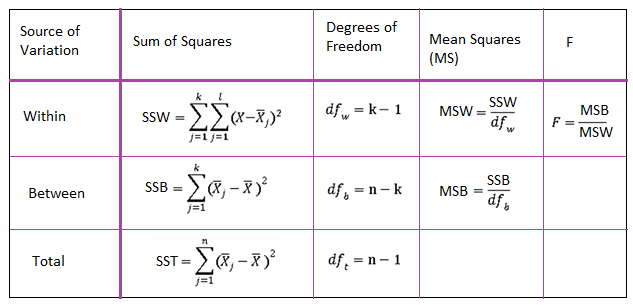

In [ ]:
# The numerical variables 
numerical=df.select_dtypes(include=['int64','float']).columns.tolist()
print(numerical)

* Using the analysis of variance (ANOVA) test, we want to determine if there is a statistically significant relationship between a numerical variable and the categorical target variable. Our p-value threshold is 0.01.

In [ ]:
df.describe().T.round(2)

In [ ]:
# define a function that performs the ANOVA test and returns a table
def anova_table(var_list, null_list=[]):
    for var in var_list:
        print(var.upper())
        
        anova = ols('time_in_hospital ~ {}'.format(var), data=df).fit()
        table = sm.stats.anova_lm(anova, typ=2)
        pvalue=table['PR(>F)'][0]
        if pvalue > 0.01: # adds variables that fail to reject the null hypothesis
            null_list.append(var)
        display(table)
    print(f'Fail to reject null hypothesis: {null_list}')

In [ ]:
anova_vars = ['readmitted']+numerical
anova_table(anova_vars)

> Based on the ANOVA test, we can drop the number of emergency visits since we cannot reject the null hypothesis that the averages for each class are similar, the p-value is greater than our threshold of 0.01.

In [ ]:
# drop number_emergency column
df = df.drop(columns=['number_emergency'])

# One Hot Encoding

Binary columns will be replaced with 0 for No and 1 for Yes. In the gender column, Male and Female will be replaced with 0 and 1 respectively.

In [ ]:
# Unique Values of Each Features
for i in df:
    print(f'{i}:\n{sorted(df[i].unique())}\n')

In [ ]:
df_dummy = pd.get_dummies(df,drop_first=True)
df_dummy.head()

# Are the features that affect readmissions correlated with each other?

If the correlation value is greater than 0.7 or less than -0.7, we have to drop one of the two columns.

The correlation map is quite large for this notebook. Instead, we are going to find each correlation coefficient individually and mark the ones that have a coefficient greater than 0.7 or less than -0.7.

In [ ]:
plt.figure(figsize=(20,5))
df_dummy.corr()["readmitted_YES"].sort_values()[:-1].plot.bar();

In [ ]:
plt.figure(figsize=(20,20))
sns.heatmap(df_dummy.corr(), cmap="coolwarm");

In [ ]:
def corrank(X, threshold=0):
    import itertools
    df = pd.DataFrame([[i,j,X.corr().abs().loc[i,j]] for i,j in list(itertools.combinations(X.corr().abs(), 2))],columns=['Feature1','Feature2','corr'])    
    df = df.sort_values(by='corr',ascending=False).reset_index(drop=True)
    return df[df['corr']>threshold]

# prints a descending list of correlation pair (Max on top)
corrank(df_dummy, 0.7)

In [ ]:
# Remove the highly collinear features from data
def remove_collinear_features(x, threshold):
    # Calculate the correlation matrix
    corr_matrix = x.corr()
    iters = range(len(corr_matrix.columns) - 1)
    drop_cols = []

    # Iterate through the correlation matrix and compare correlations
    for i in iters:
        for j in range(i+1):
            item = corr_matrix.iloc[j:(j+1), (i+1):(i+2)]
            col = item.columns
            row = item.index
            val = abs(item.values)

            # If correlation exceeds the threshold
            if val >= threshold:
                # Print the correlated features and the correlation value
                print(col.values[0], "|", row.values[0], "|", round(val[0][0], 2))
                drop_cols.append(col.values[0])

    # Drop one of each pair of correlated columns
    drops = set(drop_cols)
    x = x.drop(columns=drops)

    return x

In [ ]:
#Remove columns having more than 70% correlation
#Both positive and negative correlations are considered here
df_dummy = remove_collinear_features(df_dummy,0.70)

In [ ]:
df_dummy.shape

# saving machine learning dataset

In [ ]:
# save dataset to new file for machine learning
df_dummy.to_csv('diabetic_data_cleaned_dummy.csv')

# General Overview - Machine Learning

### Import and Load

In [ ]:
# for basic operations
import numpy as np 
import pandas as pd 

# for visualizations
import matplotlib.pyplot as plt
import seaborn as sns
from pylab import rcParams
# rcParams['figure.figsize'] = 4,4
# plt.style.use('fivethirtyeight')

from collections import Counter

# for modeling 
import sklearn
from xgboost.sklearn import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, plot_precision_recall_curve, precision_recall_curve
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import datasets, metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.decomposition import PCA

import imblearn
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

# to avoid warnings
import warnings
warnings.filterwarnings('ignore')
warnings.warn("this will not show")

In [ ]:
data = pd.read_csv('diabetic_data_cleaned_dummy.csv', index_col=0)
df = data.copy()

df.head()

### Lazy Predict with 5000 samples

In [ ]:
from lazypredict.Supervised import LazyClassifier

df_5000 = df.sample(5000,random_state=42)
y = df_5000['readmitted_YES']
X = df_5000.drop('readmitted_YES', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state =42)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

clf = LazyClassifier(verbose=0,ignore_warnings=True, custom_metric=None)
models,predictions = clf.fit(X_train, X_test, y_train, y_test)
models

### Split Data

In [ ]:
ax = df['readmitted_YES'].value_counts(normalize=True).plot.bar()
def labels(ax):
    for p in ax.patches:
        ax.annotate(f"%{p.get_height()*100:.2f}", (p.get_x() + 0.15, p.get_height() * 1.005),size=11)
labels(ax)

In [ ]:
# separating the dependent and independent data
X = df.drop('readmitted_YES', axis=1)
y = df['readmitted_YES']

# the function train_test_split creates random data samples (default: 75-25%)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# getting the shapes
print(f"""shape of X_train: {X_train.shape}
shape of X_test\t: {X_test.shape}
shape of y_train: {y_train.shape}
shape of y_test\t: {y_test.shape}""")

### Data Scaling

In [ ]:
# creating a standard scaler
sc = StandardScaler()

# fitting independent data to the model
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

### Iteration 1: (Unbalanced data)
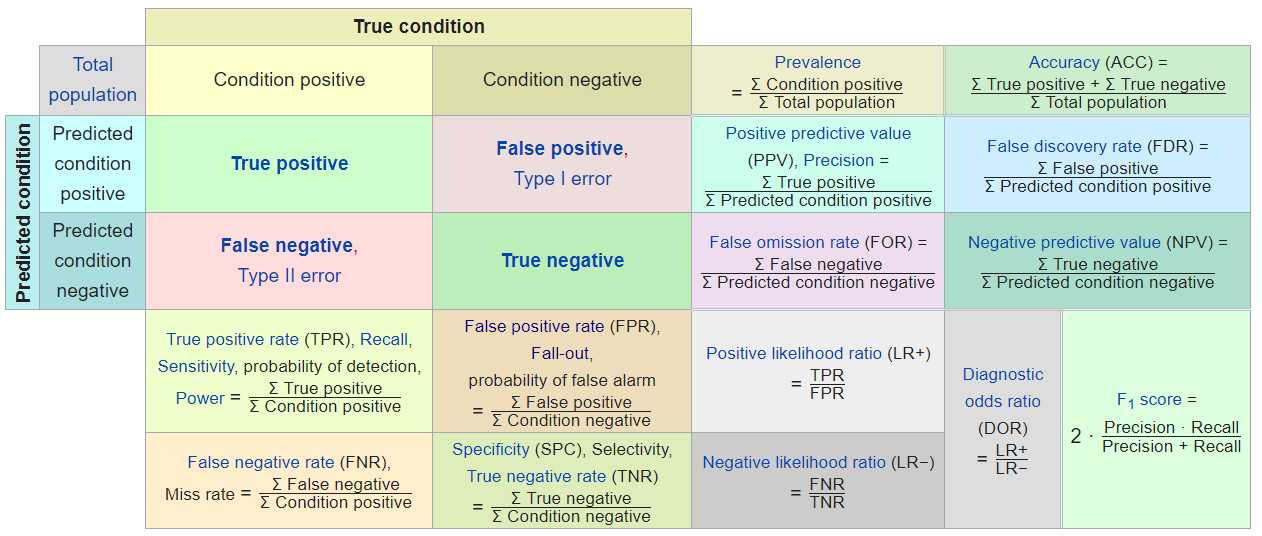

In [ ]:
cv_acc_train = {}
cv_acc_test = {}
cv_TPR = {}
cv_FPR = {}
cv_AUC = {}

In [ ]:
def plot_result(model, name:str):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Evaluation based on a 10-fold cross-validation
    scoring = ['balanced_accuracy', 'recall_macro']
    scores_train = cross_val_score(model, X_train, y_train, cv=10, scoring = 'balanced_accuracy')
    scores_test = cross_val_score(model, X_test, y_test, cv=10, scoring = 'balanced_accuracy')  
    cv_acc_train[name] = round(scores_train.mean(), 4)*100  # balanced accuracy
    cv_acc_test[name] = round(scores_test.mean(), 4)*100  # balanced accuracy
    cv_TPR[name] = (confusion_matrix(y_test, y_pred)[1][1]/confusion_matrix(y_test, y_pred)[1].sum())*100  # recall (Max)
    cv_FPR[name] = (confusion_matrix(y_test, y_pred)[0][1]/confusion_matrix(y_test, y_pred)[0].sum())*100  # fallout (Min)
    
    # accuracy scores
    print('Average Balanced Accuracy (CV=10), Test Set:', scores_test.mean())  
    print('Average Balanced Accuracy (CV=10), Training Set: ', scores_train.mean())

    # print classification report
    print(classification_report(y_test, y_pred, zero_division=0))

    # Plot Confusion Matrix
    plot_confusion_matrix(model, X_test, y_test)
    plt.show()

### 1-Decision tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_score
from sklearn.metrics import plot_confusion_matrix, classification_report, confusion_matrix

In [ ]:
dtc = DecisionTreeClassifier()
plot_result(dtc, "dtc")

In [ ]:
# plot tree
# plt.figure(figsize=(16,6))
# plot_tree(dtc, filled = True, class_names=["-1", "1"], feature_names=X.columns, fontsize=11);

In [ ]:
cv_acc_train, cv_acc_test, cv_TPR, cv_FPR

### 2-Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lr = LogisticRegression()
plot_result(lr, "lr")

### 3-SVC

In [ ]:
# svc = SVC(probability=True)  # default values
# plot_result(svc, "svc")

### 4-NearestCentroid

In [ ]:
from sklearn.neighbors import NearestCentroid
from sklearn.metrics import plot_confusion_matrix, classification_report, confusion_matrix

In [ ]:
nc = NearestCentroid()
plot_result(nc, "nc")

### 5-Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rfc = RandomForestClassifier()
plot_result(rfc, "rfc")

In [ ]:
def plot_feature_importances(model):
    feature_imp = pd.Series(model.feature_importances_,index=X.columns).sort_values(ascending=False)[:10]

    sns.barplot(x=feature_imp, y=feature_imp.index)
    plt.title("Feature Importance")
    plt.show()

    print(f"Top 10 Feature Importance for {str(model).split('(')[0]}\n\n",feature_imp[:10],sep='')

In [ ]:
plot_feature_importances(rfc)

### 6-Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
gbc = GradientBoostingClassifier(random_state=42)
plot_result(gbc, "gbc")

In [ ]:
plot_feature_importances(gbc)

### 7-Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
nb = GaussianNB()
plot_result(nb, "nb")

### 8-kNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier()
plot_result(knn, "knn")

### 9-XGBOOST

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score

In [ ]:
xgb = XGBClassifier(eval_metric = "logloss")
plot_result(xgb, "xgb")

In [ ]:
plot_feature_importances(xgb)

In [ ]:
from xgboost import plot_importance
plot_importance(xgb,max_num_features=10)
plt.xlabel('The F-Score for each features')
plt.ylabel('Importances')
plt.show()

### Evaluation (iteration 1)

In [ ]:

def AUC(cv_AUC, X_test=X_test):
    dtc_auc= roc_auc_score(y_test,dtc.predict(X_test)) #Decision Tree Classifier
    lr_auc= roc_auc_score(y_test, lr.decision_function(X_test))#logistic regression
#     svc_auc= roc_auc_score(y_test, svc.decision_function(X_test))#Support Vector Classifier
    nc_auc= roc_auc_score(y_test, nc.predict(X_test))#Nearest Centroid Classifier
    rfc_auc= roc_auc_score(y_test, rfc.predict_proba(X_test)[:,1])#Randomforest Classifier
    gbc_auc= roc_auc_score(y_test, gbc.predict_proba(X_test)[:,1])#GradientBoosting Classifier
    nb_auc= roc_auc_score(y_test, nb.predict_proba(X_test)[:,1])#Naive Bayes Classifier
    knn_auc= roc_auc_score(y_test, knn.predict(X_test))#KNeighbors Classifier
    xgb_auc= roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1])#XGBoost Classifier

    cv_AUC={'dtc': dtc_auc,
           'lr': lr_auc,
#            'svc':svc_auc,
           'nc':nc_auc,
           'rfc':rfc_auc,
           'gbc':gbc_auc,
           'nb':nb_auc,
           'knn':knn_auc,
           'xgb':xgb_auc}
    return cv_AUC

In [ ]:
cv_AUC = AUC(cv_AUC)
df_eval = pd.DataFrame(data={'model': list(cv_acc_test.keys()), 
                             'bal_acc_train':list(cv_acc_train.values()),
                             'bal_acc_test': list(cv_acc_test.values()), 
                             'recall': list(cv_TPR.values()), 
                             'fallout':list(cv_FPR.values()),
                              'AUC': list(cv_AUC.values())}).round(2)
df_eval

In [ ]:
def plot_ROC(X_test=X_test, y_test=y_test):
    fpr_dtc, tpr_dtc, thresholds = roc_curve(y_test,dtc.predict(X_test)) #Decision Tree Classifier
    fpr_lr, tpr_lr, thresholds = roc_curve(y_test, lr.decision_function(X_test))#logistic regression
#     fpr_svc, tpr_svc, thresholds = roc_curve(y_test, svc.decision_function(X_test))#Support Vector Classifier
    fpr_nc, tpr_nc, thresholds = roc_curve(y_test, nc.predict(X_test))#Nearest Centroid Classifier
    fpr_rfc, tpr_rfc, thresholds = roc_curve(y_test, rfc.predict_proba(X_test)[:,1])#Randomforest Classifier
    fpr_gbc, tpr_gbc, thresholds = roc_curve(y_test, gbc.predict_proba(X_test)[:,1])#GradientBoosting Classifier
    fpr_nb, tpr_nb, thresholds = roc_curve(y_test, nb.predict_proba(X_test)[:,1])#Naive Bayes Classifier
    fpr_knn, tpr_knn, thresholds = roc_curve(y_test, knn.predict(X_test))#KNeighbors Classifier
    fpr_xgb, tpr_xgb, thresholds = roc_curve(y_test, xgb.predict_proba(X_test)[:,1])#XGBoost Classifier

    #compare the ROC curve between different models
    plt.figure(figsize=(10,10))
    plt.plot(fpr_dtc, tpr_dtc, label='Decision Tree Classifier')
    plt.plot(fpr_lr, tpr_lr, label='Logistic Regression')
#     plt.plot(fpr_svc, tpr_svc, label='Support Vector Classifier')
    plt.plot(fpr_nc, tpr_nc, label='Nearest Centroid Classifier')
    plt.plot(fpr_rfc, tpr_rfc, label='Randomforest Classifier')
    plt.plot(fpr_gbc, tpr_gbc, label='GradientBoosting Classifier')
    plt.plot(fpr_nb, tpr_nb, label='Naive Bayes Classifier')
    plt.plot(fpr_knn, tpr_knn, label='KNeighbors Classifier')
    plt.plot(fpr_xgb, tpr_xgb, label='XGBoost Classifier')

    plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
             label='random', alpha=.8)
    plt.xlim([0,1])
    plt.ylim([0,1])
    plt.xticks(np.arange(0,1.1,0.1))
    plt.yticks(np.arange(0,1.1,0.1))
    plt.grid()
    plt.legend()
    plt.axes().set_aspect('equal')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

plot_ROC()

In [ ]:
fig, ax = plt.subplots(1,4, figsize=(20, 4))
sns.barplot(x="bal_acc_train", y="model", data=df_eval.sort_values(by="recall"), ax=ax[0])
ax[0].set_title("Unbalanced Train Acc")
sns.barplot(x="bal_acc_test", y="model", data=df_eval.sort_values(by="recall"), ax=ax[1])
ax[1].set_title("Unbalanced Test Acc")
sns.barplot(x="recall", y="model", data=df_eval.sort_values(by="recall"), ax=ax[2])
ax[2].set_title("Unbalanced Test TPR")
sns.barplot(x="fallout", y="model", data=df_eval.sort_values(by="recall"), ax=ax[3])
ax[3].set_title("Unbalanced Test FPR")
plt.show()

> NaiveBayes gave high BalanceAccuracy and TPR_Score (Recall), but it gave the poor FPR_Score (Fallout) in this unbalanced data set.

### Iteration 2: (Oversampling with SMOTE)

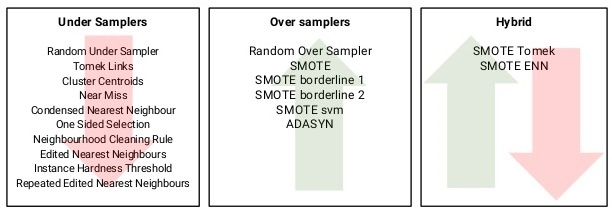

### Balancing data

In [ ]:
y_test.value_counts(normalize=True)

In [ ]:
y_train.value_counts(normalize=True)

In [ ]:
# pip install imblearn
from imblearn import under_sampling, over_sampling
from imblearn.over_sampling import SMOTE

In [ ]:
oversmote = SMOTE()
X_train_os, y_train_os= oversmote.fit_resample(X_train, y_train)

In [ ]:
ax = y_train_os.value_counts().plot.bar(color=["blue", "red"])
def labels(ax):
    for p in ax.patches:
        ax.annotate(f"{p.get_height()}", (p.get_x() + 0.15, p.get_height()+200),size=8)
labels(ax)
plt.show()

In [ ]:
X_train_os.shape

### Use algorithms

In [ ]:
cv_acc_balance_train = {}
cv_acc_balance_test = {}
cv_TPR_balance = {}
cv_FPR_balance = {}
cv_AUC_balance = {}

In [ ]:
def plot_result_smote(model, name:str):
    model.fit(X_train_os, y_train_os)
    y_pred = model.predict(X_test)

    # Evaluation based on a 10-fold cross-validation
    scoring = ['balanced_accuracy', 'recall_macro']
    scores_train = cross_val_score(model, X_train, y_train, cv=10, scoring = 'balanced_accuracy')
    scores_test = cross_val_score(model, X_test, y_test, cv=10, scoring = 'balanced_accuracy')
    cv_acc_balance_train[name] = round(scores_train.mean(), 4)*100  # balanced accuracy
    cv_acc_balance_test[name] = round(scores_test.mean(), 4)*100  # balanced accuracy
    cv_TPR_balance[name] = (confusion_matrix(y_test, y_pred)[1][1]/confusion_matrix(y_test, y_pred)[1].sum())*100  # recall (max)
    cv_FPR_balance[name] = (confusion_matrix(y_test, y_pred)[0][1]/confusion_matrix(y_test, y_pred)[0].sum())*100  # fallout (min)
    
    # accuracy scores
    print('Average Balanced Accuracy (CV=10), Test Set:', scores_test.mean())  
    print('Average Balanced Accuracy (CV=10), Training Set: ', scores_train.mean())

    # print classification report
    print(classification_report(y_test, y_pred, zero_division=0))

    # Plot Confusion Matrix
    plot_confusion_matrix(model, X_test, y_test)
    plt.show()

In [ ]:
# Decision tree
dtc = DecisionTreeClassifier()

plot_result_smote(dtc, "dtc")

In [ ]:
# Logistic Regression
lr = LogisticRegression()
plot_result_smote(lr, "lr")

In [ ]:
# NearestCentroid
nc = NearestCentroid()
plot_result_smote(nc, "nc")

In [ ]:
# # SVC
# svc = SVC()
# plot_result_smote(svc, "svc")

In [ ]:
# Random Forest
rfc = RandomForestClassifier()
plot_result_smote(rfc, "rfc")

In [ ]:
# Gradient Boost
gbc = GradientBoostingClassifier(random_state=42)
plot_result_smote(gbc, "gbc")

In [ ]:
# Naive Bayes
nb = GaussianNB()
plot_result_smote(nb, "nb")

In [ ]:
# kNN
knn = KNeighborsClassifier()
plot_result_smote(knn, "knn")

In [ ]:
# XGBOOST
xgb = XGBClassifier(eval_metric = "logloss", random_state=42)
plot_result_smote(xgb, "xgb")

In [ ]:
cv_AUC_balance = AUC(cv_AUC_balance)

In [ ]:
df_eval_smote = pd.DataFrame(data={'model': list(cv_acc_balance_test.keys()), 
                                   'bal_acc_train':list(cv_acc_balance_train.values()),
                                   'bal_acc_test': list(cv_acc_balance_test.values()),
                                   'recall': list(cv_TPR_balance.values()), 
                                   'fallout':list(cv_FPR_balance.values()),
                                   'AUC': list(cv_AUC_balance.values())}).round(2)
df_eval_smote

In [ ]:
fig, ax = plt.subplots(2,4, figsize=(20, 8))

sns.barplot(x="bal_acc_train", y="model", data=df_eval.sort_values(by="recall"), ax=ax[0,0])
ax[0,0].set_title("Unbalanced Train Acc")
sns.barplot(x="bal_acc_test", y="model", data=df_eval.sort_values(by="recall"), ax=ax[0,1])
ax[0,1].set_title("Unbalanced Test Acc")
sns.barplot(x="recall", y="model", data=df_eval.sort_values(by="recall"), ax=ax[0,2])
ax[0,2].set_title("Unbalanced Test TPR")
sns.barplot(x="fallout", y="model", data=df_eval.sort_values(by="recall"), ax=ax[0,3])
ax[0,3].set_title("Unbalanced Test FPR")

sns.barplot(x="bal_acc_train", y="model", data=df_eval_smote.sort_values(by="recall"), ax=ax[1,0])
ax[1,0].set_title("Smote Model Train Acc")
sns.barplot(x="bal_acc_test", y="model", data=df_eval_smote.sort_values(by="recall"), ax=ax[1,1])
ax[1,1].set_title("Smote Model Test Acc")
sns.barplot(x="recall", y="model", data=df_eval_smote.sort_values(by="recall"), ax=ax[1,2])
ax[1,2].set_title("Smote Model Test TPR")
sns.barplot(x="fallout", y="model", data=df_eval_smote.sort_values(by="recall"), ax=ax[1,3])
ax[1,3].set_title("Smote Model Test FPR")

plt.tight_layout()
plt.show()

In [ ]:
plot_ROC()

GradientBoosting yielded the optimized result as better FPR and relative mean strong recall scores. The balance accuracy is also relatively good.

## Iteration 3: (with RUS)

In [ ]:
import imblearn
from imblearn.under_sampling import RandomUnderSampler, EditedNearestNeighbours, NearMiss

In [ ]:
under_sampler = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = under_sampler.fit_sample(X_train, y_train)

In [ ]:
ax = y_train_rus.value_counts().plot.bar(color=["blue", "red"])
labels(ax)
plt.show()

#### Use Algorithm

In [ ]:
cv_acc_rus_train = {}
cv_acc_rus_test = {}
cv_TPR_rus = {}
cv_FPR_rus = {}
cv_AUC_rus = {}

In [ ]:
def plot_result_rus(model, name:str):
    model.fit(X_train_rus, y_train_rus)
    y_pred = model.predict(X_test)

    # Evaluation based on a 10-fold cross-validation
    scoring = ['balanced_accuracy', 'recall_macro']
    scores_train = cross_val_score(model, X_train, y_train, cv=10, scoring = 'balanced_accuracy')
    scores_test = cross_val_score(model, X_test, y_test, cv=10, scoring = 'balanced_accuracy')
    cv_acc_rus_train[name] = round(scores_train.mean(), 4)*100  # balanced accuracy
    cv_acc_rus_test[name] = round(scores_test.mean(), 4)*100  # balanced accuracy
    cv_TPR_rus[name] = (confusion_matrix(y_test, y_pred)[1][1]/confusion_matrix(y_test, y_pred)[1].sum())*100  # recall (max)
    cv_FPR_rus[name] = (confusion_matrix(y_test, y_pred)[0][1]/confusion_matrix(y_test, y_pred)[0].sum())*100  # fallout (min)
    
    # accuracy scores
    print('Average Balanced Accuracy (CV=10), Test Set:', scores_test.mean())  
    print('Average Balanced Accuracy (CV=10), Training Set: ', scores_train.mean())

    # print classification report
    print(classification_report(y_test, y_pred, zero_division=0))

    # Plot Confusion Matrix
    plot_confusion_matrix(model, X_test, y_test)
    plt.show()

In [ ]:
# Decision tree
dtc = DecisionTreeClassifier()

plot_result_rus(dtc, "dtc")

In [ ]:
# Logistic Regression
lr = LogisticRegression()
plot_result_rus(lr, "lr")

In [ ]:
# NearestCentroid
nc = NearestCentroid()
plot_result_rus(nc, "nc")

In [ ]:
# # SVC
# svc = SVC()
# plot_result_rus(svc, "svc")

In [ ]:
# Random Forest
rfc = RandomForestClassifier()
plot_result_rus(rfc, "rfc")

In [ ]:
# Gradient Boost
gbc = GradientBoostingClassifier(random_state=42)
plot_result_rus(gbc, "gbc")

In [ ]:
# Naive Bayes
nb = GaussianNB()
plot_result_rus(nb, "nb")

In [ ]:
# kNN
knn = KNeighborsClassifier()
plot_result_rus(knn, "knn")

In [ ]:
# XGBOOST
xgb = XGBClassifier(eval_metric = "logloss",random_state=42)
plot_result_rus(xgb, "xgb");

In [ ]:
cv_AUC_rus = AUC(cv_AUC_rus)

In [ ]:
df_eval_rus = pd.DataFrame(data={'model': list(cv_acc_rus_train.keys()), 
                             'bal_acc_train':list(cv_acc_rus_train.values()),
                             'bal_acc_test': list(cv_acc_rus_test.values()), 
                             'recall': list(cv_TPR_rus.values()), 
                             'fallout':list(cv_FPR_rus.values()),
                             'AUC': list(cv_AUC_rus.values())}).round(2)    
df_eval_rus

In [ ]:
fig, ax = plt.subplots(3,4, figsize=(20, 12))

sns.barplot(x="bal_acc_train", y="model", data=df_eval.sort_values(by="recall"), ax=ax[0,0])
ax[0,0].set_title("Unbalanced Train Acc")
sns.barplot(x="bal_acc_test", y="model", data=df_eval.sort_values(by="recall"), ax=ax[0,1])
ax[0,1].set_title("Unbalanced Test Acc")
sns.barplot(x="recall", y="model", data=df_eval.sort_values(by="recall"), ax=ax[0,2])
ax[0,2].set_title("Unbalanced Test TPR")
sns.barplot(x="fallout", y="model", data=df_eval.sort_values(by="recall"), ax=ax[0,3])
ax[0,3].set_title("Unbalanced Test FPR")

sns.barplot(x="bal_acc_train", y="model", data=df_eval_smote.sort_values(by="recall"), ax=ax[1,0])
ax[1,0].set_title("Smote Model Train Acc")
sns.barplot(x="bal_acc_test", y="model", data=df_eval_smote.sort_values(by="recall"), ax=ax[1,1])
ax[1,1].set_title("Smote Model Test Acc")
sns.barplot(x="recall", y="model", data=df_eval_smote.sort_values(by="recall"), ax=ax[1,2])
ax[1,2].set_title("Smote Model Test TPR")
sns.barplot(x="fallout", y="model", data=df_eval_smote.sort_values(by="recall"), ax=ax[1,3])
ax[1,3].set_title("Smote Model Test FPR")

sns.barplot(x="bal_acc_train", y="model", data=df_eval_rus.sort_values(by="recall"), ax=ax[2,0])
ax[2,0].set_title("RUS_Featured Model Test Acc")
sns.barplot(x="bal_acc_test", y="model", data=df_eval_rus.sort_values(by="recall"), ax=ax[2,1])
ax[2,1].set_title("RUS_Featured Model Test Acc")
sns.barplot(x="recall", y="model", data=df_eval_rus.sort_values(by="recall"), ax=ax[2,2])
ax[2,2].set_title("RUS_Featured Model Test TPR")
sns.barplot(x="fallout", y="model", data=df_eval_rus.sort_values(by="recall"), ax=ax[2,3])
ax[2,3].set_title("RUS_Featured Model Test FPR")

plt.tight_layout()
plt.show()

In [ ]:
plot_ROC()

## Iteration 4: (with SMOTE and PCA)

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca = PCA().fit(X_train_os)

In [ ]:
fig, ax = plt.subplots(figsize=(20,8))
xi = np.arange(0, 54, step=1)
y = np.cumsum(pca.explained_variance_ratio_[0:160:1])

plt.ylim(0.0,1.1)
plt.plot(xi, y, marker='.', linestyle='--', color='b')

plt.xlabel('Number of Components')
plt.xticks(np.arange(0, 54, step=2), rotation=90) #change from 0-based array index to 1-based human-readable label
plt.ylabel('Cumulative variance (%)')
plt.title('The number of components needed to explain variance')

plt.axhline(y=0.95, color='r', linestyle='-')
plt.text(0.5, 0.85, '95% cut-off threshold', color = 'red', fontsize=16)

ax.grid(axis='x')
plt.show()

It looks like n_components = 43 is suitable for% 95 total explained variance,

In [ ]:
pca = PCA(n_components=43)
pca.fit(X_train_os)
per_var = np.round(pca.explained_variance_ratio_ * 100, 1)
labels = ['PC' + str(x) for x in range(1,len(per_var)+1)]

plt.figure(figsize=(20,6))
plt.bar(x=range(len(per_var)), height=per_var, tick_label=labels)
plt.title('Total explained variance {}'.format(np.round(sum(per_var),2)))
plt.ylabel('Explained variance in percent')
plt.xticks(rotation=90)
plt.show()

In [ ]:
X_train_os_pca = pca.transform(X_train_os)
pd.DataFrame(X_train_os_pca)

The loads (loading scores) indicate "how high a variable X loads on a factor Y". 

(The i-th principal components can be selected via i in pca.components_ [0].)

In [ ]:
# Top 20 columns that have the greatest impact
loading_scores = pd.Series(pca.components_[0], index=X.columns)
loading_scores.abs().sort_values(ascending=False)[:20]

#### Use Algorithm

In [ ]:
X_test_pca = pca.transform(X_test)

In [ ]:
cv_acc_balance_train_pca = {}
cv_acc_balance_test_pca = {}
cv_TPR_balance_pca = {}
cv_FPR_balance_pca = {}
cv_AUC_balance_pca = {}

In [ ]:
def plot_result_smoted_pca(model, name:str):
    model.fit(X_train_os_pca, y_train_os)
    y_pred = model.predict(X_test_pca)

    # Evaluation based on a 10-fold cross-validation
    scoring = ['balanced_accuracy', 'recall_macro']
    scores_train = cross_val_score(model, X_train_os_pca, y_train_os, cv=10, scoring = 'balanced_accuracy')
    scores_test = cross_val_score(model, X_test_pca, y_test, cv=10, scoring = 'balanced_accuracy')
    cv_acc_balance_train_pca[name] = round(scores_train.mean(), 4)*100  # balanced accuracy
    cv_acc_balance_test_pca[name] = round(scores_test.mean(), 4)*100  # balanced accuracy
    cv_TPR_balance_pca[name] = (confusion_matrix(y_test, y_pred)[1][1]/confusion_matrix(y_test, y_pred)[1].sum())*100  # recall (max)
    cv_FPR_balance_pca[name] = (confusion_matrix(y_test, y_pred)[0][1]/confusion_matrix(y_test, y_pred)[0].sum())*100  # fallout (min)

    # accuracy scores
    print('Average Balanced Accuracy (CV=10), Test Set:', scores_test.mean())  
    print('Average Balanced Accuracy (CV=10), Training Set: ', scores_train.mean())

    # print classification report
    print(classification_report(y_test, y_pred, zero_division=0))

    # Plot confusion matrix
    plt.figure(figsize=(3,3))
    plot_confusion_matrix(model, X_test_pca, y_test)
    plt.show()

In [ ]:
# Decision tree
dtc = DecisionTreeClassifier()
plot_result_smoted_pca(dtc, "dtc")

In [ ]:
# Logistic Regression
lr = LogisticRegression()
plot_result_smoted_pca(lr, "lr")

In [ ]:
# NearestCentroid
nc = NearestCentroid()
plot_result_smoted_pca(nc, "nc")

In [ ]:
# # SVC
# svc = SVC()
# plot_result_smoted_pca(svc, "svc")

In [ ]:
# Random Forest
rfc = RandomForestClassifier()
plot_result_smoted_pca(rfc, "rfc")

In [ ]:
# Gradient Boost
gbc = GradientBoostingClassifier()
plot_result_smoted_pca(gbc, "gbc")

In [ ]:
# Naive Bayes
nb = GaussianNB()
plot_result_smoted_pca(nb, "nb")

In [ ]:
# kNN
knn = KNeighborsClassifier()
plot_result_smoted_pca(knn, "knn")

In [ ]:
# XGBOOST
xgb = XGBClassifier(eval_metric = "logloss")
plot_result_smoted_pca(xgb, "xgb");

In [ ]:
cv_AUC_balance_pca = AUC(cv_AUC_balance_pca, X_test_pca)
cv_AUC_balance_pca

In [ ]:
df_eval_smote_pca = pd.DataFrame(data={'model': list(cv_acc_balance_train_pca.keys()), 
                                       'bal_acc_train':list(cv_acc_balance_train_pca.values()),
                                       'bal_acc_test': list(cv_acc_balance_test_pca.values()),
                                       'recall': list(cv_TPR_balance_pca.values()), 
                                       'fallout':list(cv_FPR_balance_pca.values()),
                                       'AUC': list(cv_AUC_rus.values())}).round(2)
df_eval_smote_pca

In [ ]:
fig, ax = plt.subplots(4,4, figsize=(20, 16))

sns.barplot(x="bal_acc_train", y="model", data=df_eval.sort_values(by="recall"), ax=ax[0,0])
ax[0,0].set_title("Unbalanced Train Acc")
sns.barplot(x="bal_acc_test", y="model", data=df_eval.sort_values(by="recall"), ax=ax[0,1])
ax[0,1].set_title("Unbalanced Test Acc")
sns.barplot(x="recall", y="model", data=df_eval.sort_values(by="recall"), ax=ax[0,2])
ax[0,2].set_title("Unbalanced Test TPR")
sns.barplot(x="fallout", y="model", data=df_eval.sort_values(by="recall"), ax=ax[0,3])
ax[0,3].set_title("Unbalanced Test FPR")

sns.barplot(x="bal_acc_train", y="model", data=df_eval_smote.sort_values(by="recall"), ax=ax[1,0])
ax[1,0].set_title("Smote Model Train Acc")
sns.barplot(x="bal_acc_test", y="model", data=df_eval_smote.sort_values(by="recall"), ax=ax[1,1])
ax[1,1].set_title("Smote Model Test Acc")
sns.barplot(x="recall", y="model", data=df_eval_smote.sort_values(by="recall"), ax=ax[1,2])
ax[1,2].set_title("Smote Model Test TPR")
sns.barplot(x="fallout", y="model", data=df_eval_smote.sort_values(by="recall"), ax=ax[1,3])
ax[1,3].set_title("Smote Model Test FPR")

sns.barplot(x="bal_acc_train", y="model", data=df_eval_rus.sort_values(by="recall"), ax=ax[2,0])
ax[2,0].set_title("RUS_Featured Model Test Acc")
sns.barplot(x="bal_acc_test", y="model", data=df_eval_rus.sort_values(by="recall"), ax=ax[2,1])
ax[2,1].set_title("RUS_Featured Model Test Acc")
sns.barplot(x="recall", y="model", data=df_eval_rus.sort_values(by="recall"), ax=ax[2,2])
ax[2,2].set_title("RUS_Featured Model Test TPR")
sns.barplot(x="fallout", y="model", data=df_eval_rus.sort_values(by="recall"), ax=ax[2,3])
ax[2,3].set_title("RUS_Featured Model Test FPR")

sns.barplot(x="bal_acc_train", y="model", data=df_eval_smote_pca.sort_values(by="recall"), ax=ax[3,0])
ax[3,0].set_title("Smoted_PCA Model Train Acc")
sns.barplot(x="bal_acc_test", y="model", data=df_eval_smote_pca.sort_values(by="recall"), ax=ax[3,1])
ax[3,1].set_title("Smoted_PCA Model Test Acc")
sns.barplot(x="recall", y="model", data=df_eval_smote_pca.sort_values(by="recall"), ax=ax[3,2])
ax[3,2].set_title("Smoted_PCA Model Test TPR")
sns.barplot(x="fallout", y="model", data=df_eval_smote_pca.sort_values(by="recall"), ax=ax[3,3])
ax[3,3].set_title("Smoted_PCA Model Test FPR")

plt.tight_layout()
plt.show()

In [ ]:
plot_ROC(X_test_pca)

According to Smote and PCA, none of the models really gave relatively good results.

In [ ]:
df_eval["type"] = "Unbalanced"
df_eval_smote["type"] = "Smote"
df_eval_rus["type"] = "RUS"
df_eval_smote_pca["type"] = "Smote_PCA"

In [ ]:
frames = [df_eval, df_eval_smote, df_eval_rus, df_eval_smote_pca]
df_result = pd.concat(frames, ignore_index=True)
df_result['model'] = df_result['model'].str.upper()
df_result[["recall", "fallout", "bal_acc_train", "bal_acc_test",'AUC']] = df_result[["recall", "fallout",  "bal_acc_train", "bal_acc_test",'AUC']].apply(lambda x: np.round(x, 2))

In [ ]:
df_result

In [ ]:
sns.relplot(x="recall", y="AUC", hue="model", size="bal_acc_test", 
            sizes=(40, 400), col="type", alpha=1, palette="bright", height=4, legend='full', data=df_result)

* In this plot it looks like GradientBoosting in Smote_PCA has the best scores. But There is a overfitting there, GradientBoosting in RUS(Random Under Sampling) is better. There is no overfitting. Recall:57.27, AUC:0.62, F1:58
* In the last iteration we will make hyperparameter optimization with GradientBoosting in RUS. We try to reach a better scores.

## Iteration 5: (with RUS and hyperparameter optimization)

At the end of 4 iteration, GradientBoost with only undersampled and scaled data set gave better results. In this iteration, we try to improve the GradientBoost Model with hyperparameter optimization.

In [ ]:
# Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier
under_sampler = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = under_sampler.fit_sample(X_train, y_train)

params={"learning_rate": [1],
     "min_samples_split": [50, 10, 2],
       "min_samples_leaf": [1, 5, 10],
       "max_depth":[3,4,5],
       "subsample":[0.5, 1.0],
       "n_estimators":[10, 50, 100],
       "random_state":[42]}

gbc_tunned = GridSearchCV(GradientBoostingClassifier(), 
                                params, 
                                n_jobs=-1, 
                                verbose=2, 
                                ).fit(X_train_rus, y_train_rus)

In [ ]:
from sklearn.metrics import plot_confusion_matrix, classification_report, confusion_matrix
print(gbc_tunned.best_estimator_)
y_pred = gbc_tunned.predict(X_test)

# AUC Score
print('AUC:', roc_auc_score(y_test, gbc_tunned.predict_proba(X_test)[:,1]))

# print classification report
print(classification_report(y_test, y_pred, zero_division=0))

# Plot confusion matrix
plt.figure(figsize=(3,3))
plot_confusion_matrix(gbc_tunned, X_test, y_test)
plt.show()

The tunned GradientBoost Model didnt give a better result.

#  Summary: 
* In this project the diabetic_data.csv dataset was analyzed by machine learning methods with 5 iterations as a classification. For each iteration one tried little by little to achieve a better model result. 
* 8 different algorithms (DecisionTree, Logistic Regression, Random Forest, Gradient Boost, NaiveBayes, Nearest Centroid, XGBOOST and kNearestNeigbour) were used. 
* After the data cleaning and EDA process, the data set was scaled with StandartScaler because there were many large and small features. After that, something special (oversampling, FeatureSelection, FeatureExtraction, HyperParameter optimization) was applied in each iteration. 
* In the end, GradientBoost with only undersampled and scaled data set gave better results.